# Medical Insurance — EDA & Predictive Preview

**Author:** Mohan Krishna Thalla 
**Dataset:** `medical_insurance.csv` (100k rows, ~54 cols)  
**Goals:**  
- Understand dataset structure and quality  
- Perform rich EDA and derive actionable insights ("beyond the data")  
- Engineer features useful for modeling  
- Quick predictive preview for `annual_medical_cost` (regression) with feature importance


## 1. Environment & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Misc
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


## 2. Load data

In [2]:
DATA_PATH = "/kaggle/input/medical-insurance-cost-prediction/medical_insurance.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (100000, 54)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


# Data overview
- Display info, dtypes, missing values, and basic descriptive statistics.


## 3. Basic info

In [3]:
df.info()
display(df.describe(include='all').T)

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_id,100000.0,NaN,NaN,NaN,50000.5,28867.657797,1.0,25000.75,50000.5,75000.25,100000.0
age,100000.0,NaN,NaN,NaN,47.5215,15.988752,0.0,37.0,48.0,58.0,100.0
sex,100000,3,Female,49193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,100000,5,South,28029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
urban_rural,100000,3,Urban,60019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,100000.0,NaN,NaN,NaN,49873.905,46800.214127,1100.0,21100.0,36200.0,62200.0,1061800.0
education,100000,6,Bachelors,27996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,100000,4,Married,53252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status,100000,4,Employed,55269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
household_size,100000.0,NaN,NaN,NaN,2.4309,1.075126,1.0,2.0,2.0,3.0,9.0


alcohol_freq    30083
dtype: int64

# Data dictionary (compact)
Group columns by category (as provided in dataset README) — useful to reference while analyzing.

- **Demographics & Socioeconomic:** person_id, age, sex, region, urban_rural, income, education, marital_status, employment_status, household_size, dependents  
- **Lifestyle & Habits:** bmi, smoker, alcohol_freq, exercise_frequency, sleep_hours, stress_level  
- **Health & Clinical:** hypertension, diabetes, copd, cardiovascular, cancer_history, kidney_disease, liver_disease, arthritis, mental_health, chronic_count, systolic_bp, diastolic_bp, ldl, hba1c, risk_score, is_high_risk  
- **Utilization & Procedures:** visits_last_year, hospitalizations_last_3yrs, days_hospitalized_last_3yrs, medication_count, proc_imaging, proc_surgery, proc_psycho, proc_consult_count, proc_lab, had_major  
- **Insurance & Policy:** plan_type, network_tier, deductible, copay, policy_term_years, policy_changes_last_2yrs, provider_quality  
- **Costs & Claims:** annual_medical_cost, annual_premium, monthly_premium, claims_count, avg_claim_amount, total_claims_paid


# Exploratory Data Analysis (EDA)
We'll:
- Inspect distributions for key numeric columns
- Categorical counts
- Correlations vs `annual_medical_cost`
- Selected bivariate analyses


## 4. Key numeric distributions

In [4]:
num_cols = ['age','income','bmi','annual_medical_cost','annual_premium','monthly_premium','claims_count','avg_claim_amount']
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,47.521500,15.988752,0.00,37.0000,48.000,58.0000,100.00
income,100000.0,49873.905000,46800.214127,1100.00,21100.0000,36200.000,62200.0000,1061800.00
bmi,100000.0,26.990512,4.994883,12.00,23.6000,27.000,30.4000,50.40
annual_medical_cost,100000.0,3009.451907,3127.462822,55.55,1175.1175,2082.575,3707.9575,65724.90
annual_premium,100000.0,582.320040,399.583722,211.67,352.0700,463.585,666.6975,10962.55
monthly_premium,100000.0,48.526668,33.298640,17.64,29.3400,38.630,55.5600,913.55
claims_count,100000.0,1.621780,2.029820,0.00,0.0000,1.000,2.0000,23.00
avg_claim_amount,100000.0,656.512084,1072.660048,0.00,0.0000,318.015,872.2150,30010.53


## 5. Histograms for core numeric variables

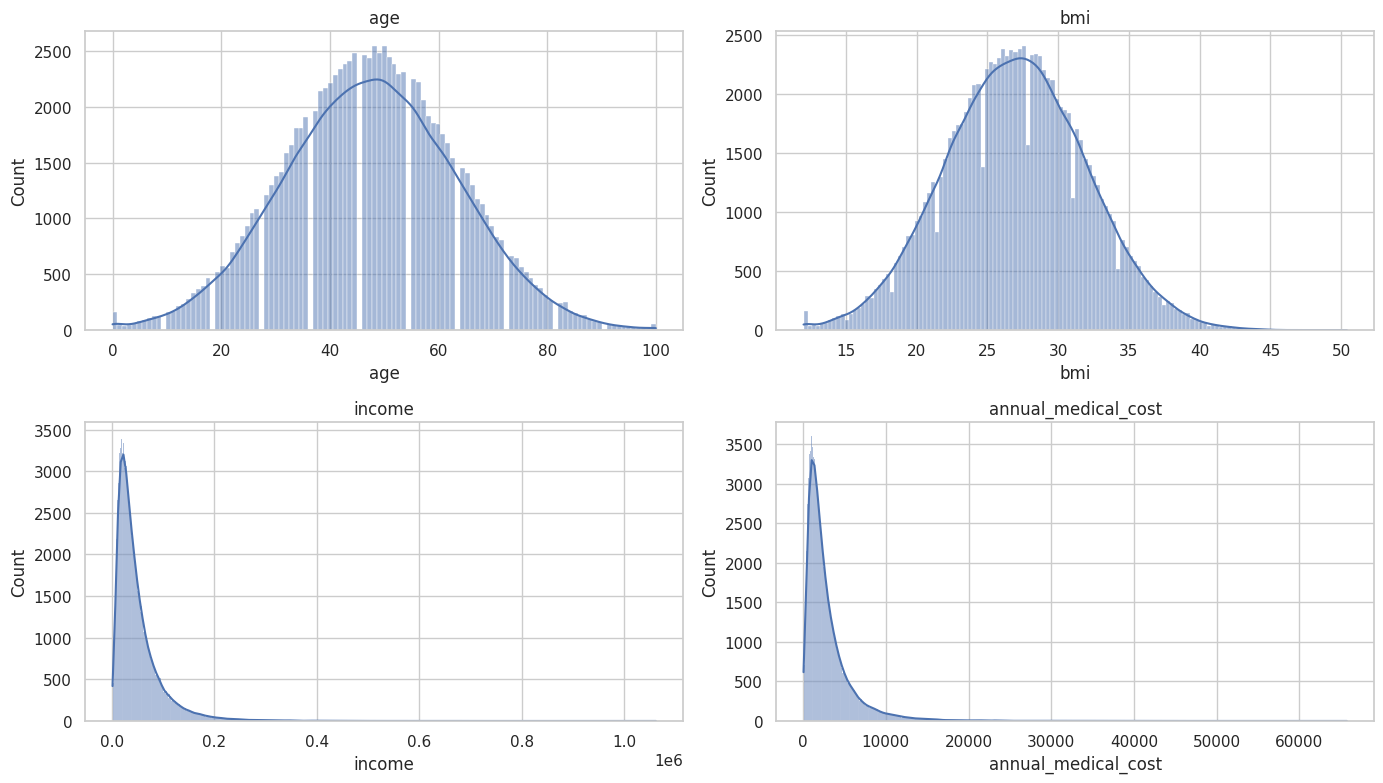

In [5]:
plt.figure(figsize=(14,8))
for i, col in enumerate(['age','bmi','income','annual_medical_cost']):
    plt.subplot(2,2,i+1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(col)
plt.tight_layout()

## 6. Categorical distributions (top categories)

In [6]:
cat_cols = ['sex','region','urban_rural','education','marital_status','employment_status','smoker','plan_type']
for c in cat_cols:
    print("---", c, "---")
    print(df[c].value_counts(normalize=True).mul(100).round(2).head(10).to_string())
    print()

--- sex ---
sex
Female    49.19
Male      48.79
Other      2.01

--- region ---
region
South      28.03
North      22.03
East       19.98
West       17.88
Central    12.08

--- urban_rural ---
urban_rural
Urban       60.02
Suburban    25.02
Rural       14.96

--- education ---
education
Bachelors       28.00
Some College    25.11
HS              24.83
Masters         13.99
No HS            5.12
Doctorate        2.96

--- marital_status ---
marital_status
Married     53.25
Single      35.72
Divorced     6.98
Widowed      4.05

--- employment_status ---
employment_status
Employed         55.27
Retired          19.86
Unemployed       12.94
Self-employed    11.93

--- smoker ---
smoker
Never      69.71
Former     18.16
Current    12.13

--- plan_type ---
plan_type
PPO    35.17
HMO    34.72
EPO    15.12
POS    14.99



# Correlation heatmap (numeric features)
Look for features that are highly correlated with `annual_medical_cost`.


## 7. Correlation with annual_medical_cost

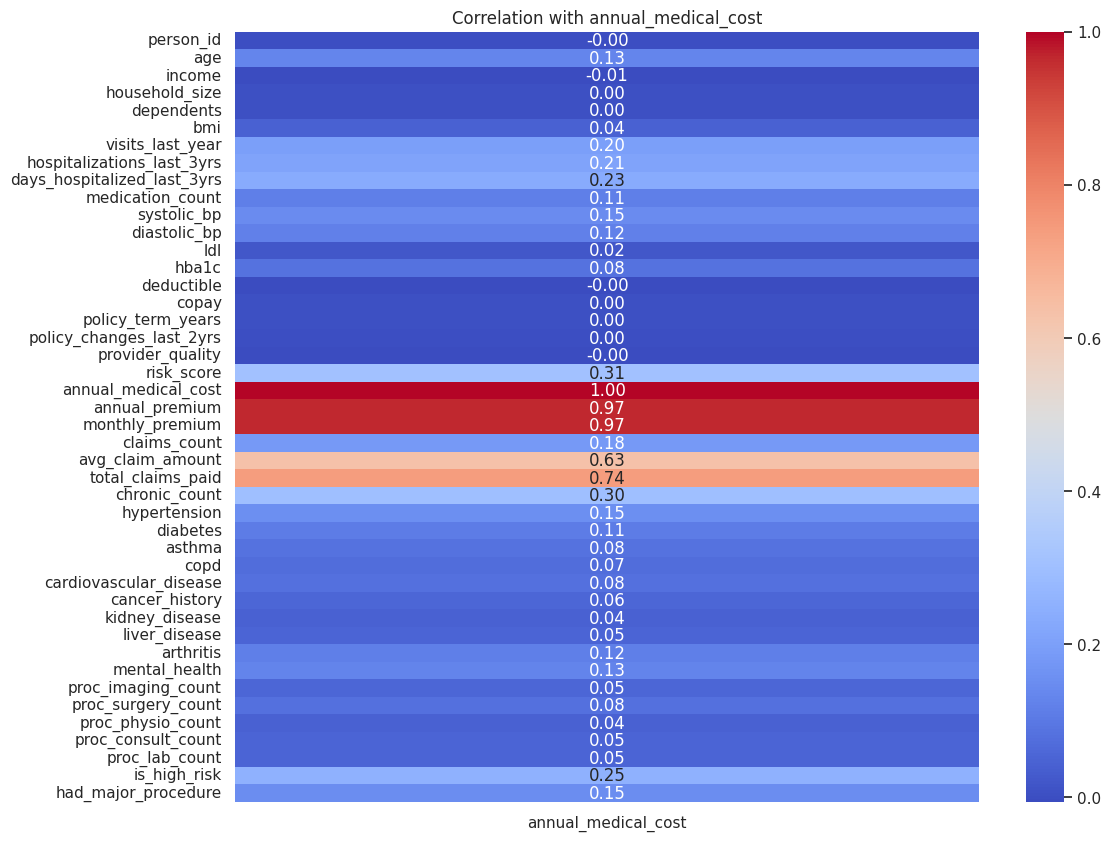

In [7]:
corr_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[corr_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr.loc[['annual_medical_cost']].T, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation with annual_medical_cost")
plt.show()

# Targeted bivariate analyses
- `age` vs cost  
- `bmi` vs cost  
- `smoker` vs cost


## 8. Age and BMI vs Cost

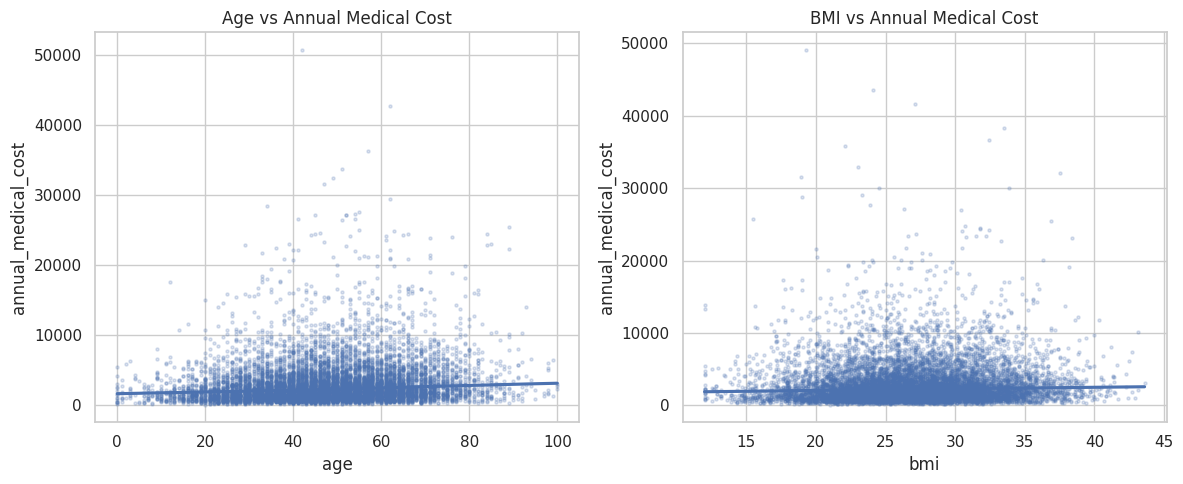

In [8]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.regplot(x='age', y='annual_medical_cost', data=df.sample(10000), scatter_kws={'s':5,'alpha':0.2}, lowess=True)
plt.title('Age vs Annual Medical Cost')

plt.subplot(1,2,2)
sns.regplot(x='bmi', y='annual_medical_cost', data=df.sample(10000), scatter_kws={'s':5,'alpha':0.2}, lowess=True)
plt.title('BMI vs Annual Medical Cost')
plt.tight_layout()

## 9. Smoker vs Cost


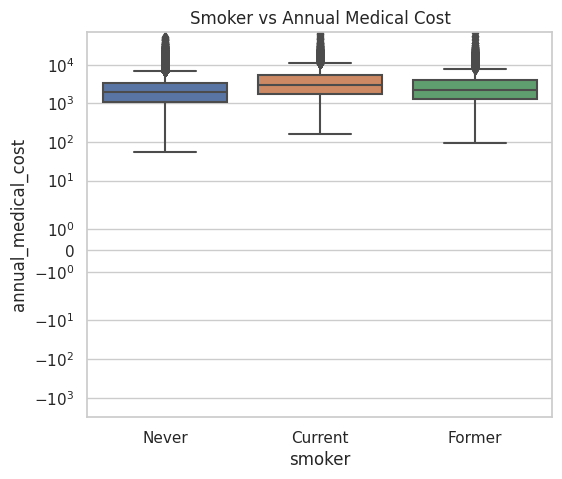

In [9]:
plt.figure(figsize=(6,5))
sns.boxplot(x='smoker', y='annual_medical_cost', data=df)
plt.yscale('symlog')
plt.title('Smoker vs Annual Medical Cost')
plt.show()

# Advanced insights — "Beyond the data"
We'll create composite metrics and examine relationships that are actionable:
1. Cost-to-Income ratio (how burdensome medical cost is relative to income)  
2. Chronic burden index (normalized chronic_count + key comorbidities)  
3. Claims efficiency: `total_claims_paid` / `annual_medical_cost` or `claims_count` relative to `annual_premium`


## 10. Derived features

In [10]:
df['cost_to_income'] = df['annual_medical_cost'] / df['income'].replace(0, np.nan)
df['cost_to_income'] = df['cost_to_income'].fillna(df['annual_medical_cost'] / df['income'].median())

# List of comorbidity columns (only use existing ones)
comorbid_cols = ['hypertension','diabetes','copd','cardiovascular',
                 'kidney_disease','liver_disease','cancer_history',
                 'arthritis','mental_health']

# Keep only columns that exist in df
existing_comorbid_cols = [c for c in comorbid_cols if c in df.columns]

# Compute comorbidity features safely
df['comorbidity_count'] = df[existing_comorbid_cols].sum(axis=1)
df['comorbidity_ratio'] = df['comorbidity_count'] / len(existing_comorbid_cols)

# Quick check
df[['cost_to_income','comorbidity_count','comorbidity_ratio']].describe().T


,count,mean,std,min,25%,50%,75%,max
cost_to_income,100000.0,0.114627,0.204305,0.000374,0.026218,0.057348,0.127296,14.119667
comorbidity_count,100000.0,0.614680,0.737492,0.000000,0.000000,0.000000,1.000000,5.000000
comorbidity_ratio,100000.0,0.076835,0.092186,0.000000,0.000000,0.000000,0.125000,0.625000


## 11. Visualize cost_to_income vs comorbidity_count

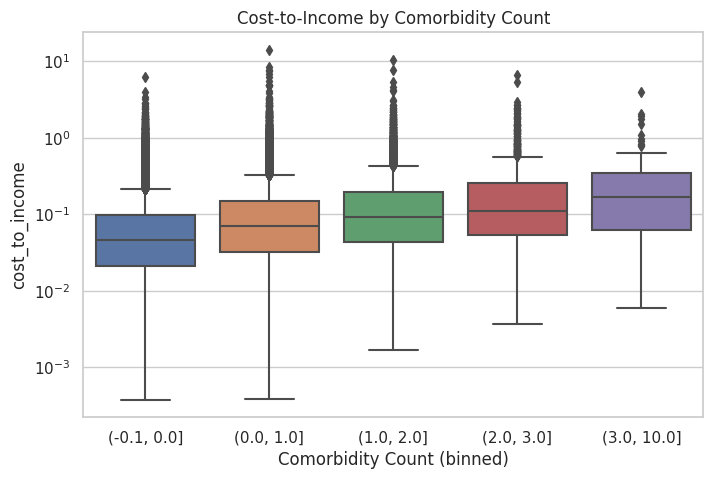

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=pd.cut(df['comorbidity_count'], bins=[-0.1,0,1,2,3,10]), y='cost_to_income', data=df)
plt.yscale('log')
plt.xlabel('Comorbidity Count (binned)')
plt.title('Cost-to-Income by Comorbidity Count')
plt.show()

# Insurance impact analysis
Investigate whether policy variables (deductible, copay, provider_quality) appear associated with medical costs and claims.

## 12. Insurance variables & cost

annual_medical_cost    1.000000
monthly_premium        0.965416
annual_premium         0.965415
copay                  0.002961
deductible            -0.002538
provider_quality      -0.003214
Name: annual_medical_cost, dtype: float64

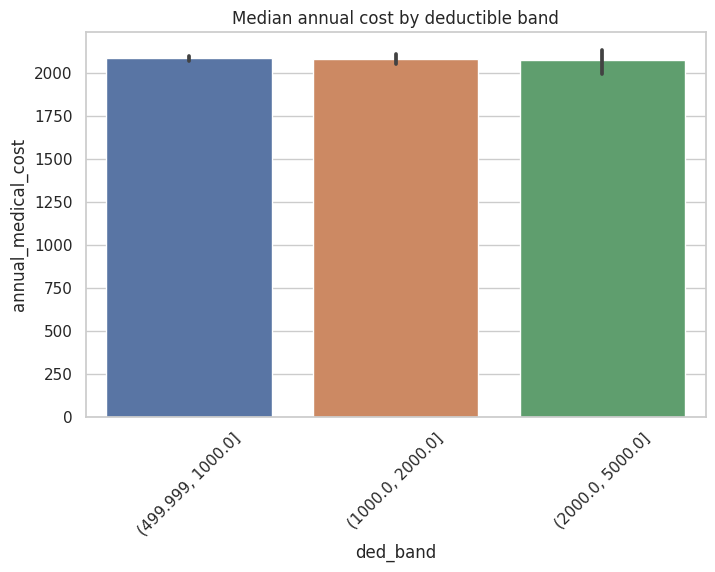

In [12]:
ins_cols = ['deductible','copay','provider_quality','annual_premium','monthly_premium']
display(df[ins_cols + ['annual_medical_cost']].corr()['annual_medical_cost'].sort_values(ascending=False))

# Deductible bands vs median cost
df['ded_band'] = pd.qcut(df['deductible'].fillna(0), q=5, duplicates='drop')
plt.figure(figsize=(8,5))
sns.barplot(x='ded_band', y='annual_medical_cost', data=df, estimator=np.median)
plt.xticks(rotation=45)
plt.title('Median annual cost by deductible band')
plt.show()

# Feature engineering suggestions (for modeling)
- Encode `is_high_risk`, `smoker`, `urban_rural`, `plan_type` as categorical  
- Create `cost_to_income` (done), `monthly_to_annual_ratio = monthly_premium * 12 / annual_premium` (sanity)  
- Use `comorbidity_count`, `chronic_count`, and `medication_count` as numeric risk indicators  
- Create interaction features: `age*bmi`, `smoker*comorbidity_count`, `income*provider_quality`


## 13. Feature engineering

In [13]:
df['age_bmi'] = df['age'] * df['bmi']
df['smoker_comorbidity'] = df['smoker'].map({0:0,1:1}) * df['comorbidity_count']
df['monthly_to_annual_ratio'] = (df['monthly_premium'] * 12) / df['annual_premium'].replace(0, np.nan)
df['monthly_to_annual_ratio'] = df['monthly_to_annual_ratio'].fillna(1)

# Predictive modeling preview — target: `annual_medical_cost`
We'll:
- Prepare a baseline pipeline
- Train a Linear Regression and a Random Forest
- Compare metrics on hold-out test set
- Show feature importances from Random Forest


## 14. Quick model prep

In [14]:
# Check if modeling is possible
feature_cols = ['age','bmi','income','comorbidity_count','medication_count',
                'visits_last_year','hospitalizations_last_3yrs','deductible',
                'copay','annual_premium','provider_quality','age_bmi',
                'smoker_comorbidity','cost_to_income']

# Keep only columns that exist
feature_cols = [c for c in feature_cols if c in df.columns]
target = 'annual_medical_cost'

# Ensure the target exists
if target not in df.columns:
    print(f"Target '{target}' not found. Modeling skipped.")
else:
    # Fill missing feature values to avoid dropping all rows
    df_model = df[feature_cols + [target]].copy()
    df_model[feature_cols] = df_model[feature_cols].fillna(0)  # or fill with median

    # Drop rows with missing target only
    df_model = df_model.dropna(subset=[target])

    if len(df_model) == 0:
        print("No rows available for modeling after handling missing values.")
    else:
        X = df_model[feature_cols]
        y = df_model[target]
        from sklearn.model_selection import train_test_split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        print("Train size:", X_train.shape, "Test size:", X_test.shape)
        # Now you can safely proceed with numeric_features and pipeline


Train size: (80000, 14) Test size: (20000, 14)


## 15. Baseline pipeline (numerical scaling + regressor)

In [15]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(transformers=[('num', num_transformer, numeric_features)], remainder='drop')

pipe_lr = Pipeline(steps=[('pre', preprocessor), ('lr', LinearRegression())])
pipe_rf = Pipeline(steps=[('pre', preprocessor), ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

def evaluate(model, X_t, y_t):
    preds = model.predict(X_t)
    return {'MAE': mean_absolute_error(y_t, preds),
            'RMSE': mean_squared_error(y_t, preds, squared=False),
            'R2': r2_score(y_t, preds)}

print("Linear Regression (test):", evaluate(pipe_lr, X_test, y_test))
print("Random Forest (test):", evaluate(pipe_rf, X_test, y_test))

Linear Regression (test): {'MAE': 457.9568031795392, 'RMSE': 797.5561962486008, 'R2': 0.935357084030273}
Random Forest (test): {'MAE': 94.18806174000001, 'RMSE': 390.9691036118438, 'R2': 0.9844660025682788}


## 16. Feature importances from Random Forest

annual_premium                0.937915
income                        0.027423
cost_to_income                0.025149
provider_quality              0.001840
bmi                           0.001390
age_bmi                       0.001179
age                           0.001124
visits_last_year              0.001083
medication_count              0.000745
deductible                    0.000739
copay                         0.000629
comorbidity_count             0.000463
hospitalizations_last_3yrs    0.000321
smoker_comorbidity            0.000000
dtype: float64

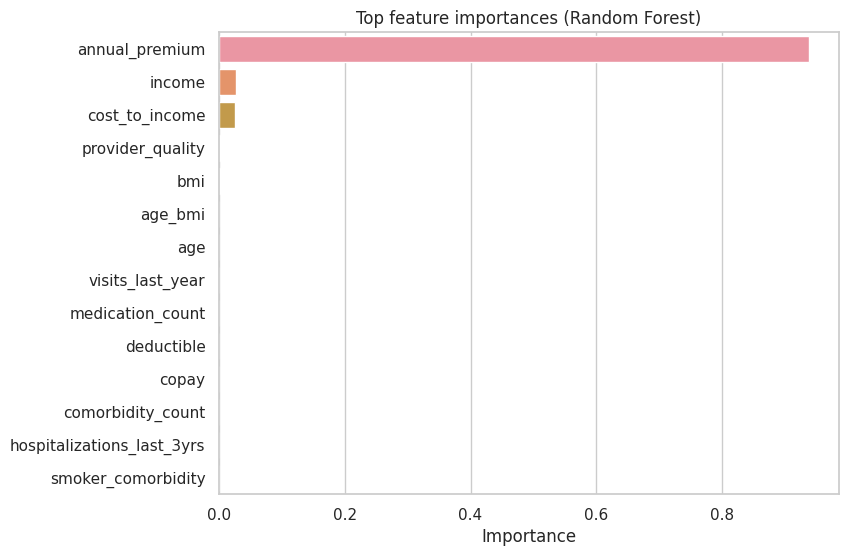

In [16]:
rf = pipe_rf.named_steps['rf']
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=numeric_features).sort_values(ascending=False)
display(feat_imp.head(20))

plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.head(15).values, y=feat_imp.head(15).index)
plt.title('Top feature importances (Random Forest)')
plt.xlabel('Importance')
plt.show()

# Model diagnostics & fairness checks (short checklist)
- Check residuals: plot predicted vs residuals and look for heteroskedasticity.  
- Evaluate model performance by subgroups: smoker vs non-smoker, region, income quintile.  
- Check for label leakage — ensure features used are available *before* the cost occurs.  
- Consider log-transforming target if heavily skewed (use `np.log1p` on target, then back-transform predictions).

## 17. Residuals plot (RF)

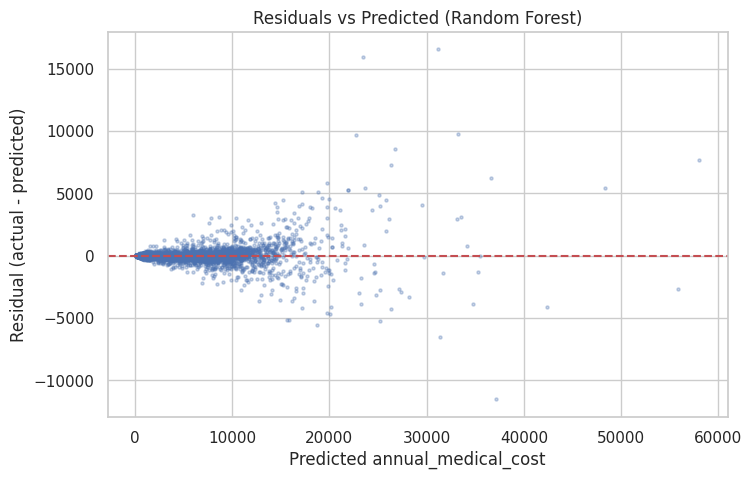

In [17]:
preds = pipe_rf.predict(X_test)
resid = y_test - preds
plt.figure(figsize=(8,5))
plt.scatter(preds, resid, s=5, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted annual_medical_cost')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residuals vs Predicted (Random Forest)')
plt.show()

# Key takeaways & next steps

**Takeaways from this notebook**
- `age`, `bmi`, and comorbidity-related features are prominent drivers of annual medical cost.  
- Smokers carry a noticeably higher distribution of costs.  
- Insurance features (deductible, premium) show relationships with cost but require causality-aware interpretation (plans may be correlated with population segments).  
- Cost distribution is heavily right-skewed — consider log-target for modeling stability.

**Next steps**
1. Add richer categorical encoding (OneHot / target encoding) for `region`, `education`, `plan_type`.  
2. Use temporal features or claims timeline (if available) to avoid leakage.  
3. Try advanced models (CatBoost/LightGBM) with proper CV and hyperparameter tuning.  
4. Perform subgroup fairness/performance checks (age groups, income bands).  
5. Build an explainability layer (SHAP) for model-level explanations if permitted on Kaggle.

# Reproducibility notes
- This notebook is intended as a starter; adjust `DATA_PATH` on Kaggle to point to your uploaded dataset.  
- For large-scale runs consider sampling (we used sampling for some plots to speed rendering).
